# LangGraph Core — State, Nodes, Conditional Edges

**Что строим:** HR-агент, в котором **граф** (а не LLM) управляет потоком.

**Архитектура:**
```
START → classify ──vacancies──► qdrant ──────────────► answer → END
                 ──salary─────► market ──────────────► answer → END
                 ──both───────► qdrant ──► market ────► answer → END
                 ──smalltalk──────────────────────────► answer → END
```

**Новые концепции:**
1. `TypedDict State` — кастомное состояние вместо `MessagesState`
2. Nodes как чистые функции `state → dict`
3. Conditional edges — маршрутизация по полям состояния

**Нить прошлого:** та же база Qdrant, тот же ретривер, те же данные.

### 0. Setup

In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [2]:
import torch
from typing import TypedDict, Annotated, Literal

from qdrant_client import QdrantClient
from langchain_qdrant import QdrantVectorStore
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_tavily import TavilySearch
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from pydantic import BaseModel
from IPython.display import display, Markdown, Image

/Users/anton/Desktop/total/Elbrus/Elbrus_projects/langgraph_agent/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/anton/Desktop/total/Elbrus/Elbrus_projects/langgraph_agent/.venv/lib/python3.13/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [3]:
COLLECTION_NAME = "vacancies_e5_small_v1"

# Та же база, тот же ретривер — нить прошлого
client = QdrantClient(path="./data/db/vacancies_db")

embeddings_model = HuggingFaceEmbeddings(
    model_name="intfloat/multilingual-e5-small",
    model_kwargs={"device": "mps" if torch.backends.mps.is_available() else "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)

vector_store = QdrantVectorStore(
    client=client,
    collection_name=COLLECTION_NAME,
    embedding=embeddings_model,
)

retriever = vector_store.as_retriever(search_kwargs={"k": 3})


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3682.44it/s]


In [ ]:
def format_docs(docs) -> str:
    parts = []
    for i, doc in enumerate(docs, 1):
        m = doc.metadata
        entry = "\n".join([
            f"=== ВАКАНСИЯ {i} ===",
            f"ID: {m.get('id', 'N/A')}",
            f"Должность: {m.get('professional_roles', 'N/A')}",
            f"Компания: {m.get('employer', 'N/A')}",
            f"Локация: {m.get('area', 'N/A')}",
            f"Скиллы: {', '.join(m.get('extracted_skills', []))}",
            f"Описание: {doc.page_content[:300]}...",
        ])
        parts.append(entry)
    return "\n\n".join(parts)


llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0,
    max_tokens=2000,
)

SALARY_DOMAINS = ["levels.fyi", "glassdoor.com", "career.habr.com", "getmatch.ru", "talent.com"]
tavily = TavilySearch(max_results=3, topic="general")


def parse_tavily(raw, max_chars: int = 1500) -> str:
    if isinstance(raw, str):
        return raw[:max_chars]
    results = raw.get("results", [])
    parts = [f"Source: {r['title']}\n{r['content']}" for r in results]
    return "\n\n".join(parts)[:max_chars]


---
### 1. Где мы остановились

В `01_03` мы построили граф из двух узлов — `agent` и `tools`:

```
START → agent → (tools_condition) → tools → agent
                                  ↓
                                 END
```

**Кто управлял потоком?** LLM: она сама решала — вызвать инструмент или ответить.

**Ограничение:** граф не «знает», что происходит внутри. Состояние — только список сообщений, нет структурированных полей для промежуточных данных.

Сегодня мы разворачиваем это: **граф управляет потоком**, LLM выполняет конкретную задачу в каждом узле.

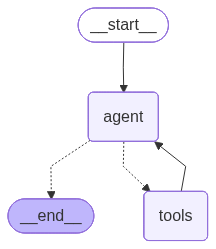

In [6]:
# Граф из 01_03 — для контраста
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import MessagesState

def _stub_agent(state): ...

old_graph = (
    StateGraph(MessagesState)
    .add_node("agent", _stub_agent)
    .add_node("tools", ToolNode([]))
    .add_edge(START, "agent")
    .add_conditional_edges("agent", tools_condition)
    .add_edge("tools", "agent")
    .compile()
)
display(Image(old_graph.get_graph().draw_mermaid_png()))

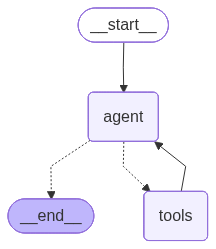

**Граф который строим сегодня** — четыре узла, два conditional edges, явное управление потоком.

---
### 2. State — кастомное состояние

`MessagesState` из `01_03` — это по сути:
```python
class MessagesState(TypedDict):
    messages: Annotated[list, add_messages]
```

Нам нужно больше — хранить **тип запроса** и **результаты каждого шага** прямо в состоянии.

In [10]:
class HRState(TypedDict):
    messages:       Annotated[list, add_messages]  # ← reducer: новые сообщения добавляются, не перезаписываются
    query_type:     str                            # ← заполняет classify_node
    qdrant_results: str                            # ← заполняет qdrant_node
    market_results: str                            # ← заполняет market_node

#### Как узлы(nodes) обновляют состояние

Каждый узел(нода) принимает полный `state` → возвращает **только изменённые поля**:

```python
def some_node(state: HRState) -> dict:
    return {"query_type": "vacancies"}  # остальные поля не трогает
```

**`add_messages` reducer** — единственное поле со специальной логикой:
вместо перезаписи новые сообщения **добавляются** в конец.
Без него каждый вызов `answer_node` перезаписывал бы историю целиком.

In [11]:
# Демонстрация: add_messages — это reducer для поля messages
from langgraph.graph.message import add_messages

existing = [HumanMessage(content="Привет")]
new_msgs = [AIMessage(content="Здравствуй!")]

merged = add_messages(existing, new_msgs)
for m in merged:
    print(f"{type(m).__name__}: {m.content}")

HumanMessage: Привет
AIMessage: Здравствуй!


In [12]:
merged

[HumanMessage(content='Привет', additional_kwargs={}, response_metadata={}, id='23b7abab-6b9b-4b23-95ad-18d942eeaa60'),
 AIMessage(content='Здравствуй!', additional_kwargs={}, response_metadata={}, id='2889aa4b-54f7-4bdd-aca7-003d4a034478', tool_calls=[], invalid_tool_calls=[])]

---
### 3. Узлы(ноды) — чистые функции

| Узел | Что делает | Пишет в state |
|---|---|---|
| `classify` | LLM определяет тип запроса | `query_type` |
| `qdrant` | Ищет вакансии в базе | `qdrant_results` |
| `market` | Ищет данные рынка через Tavily | `market_results` |
| `answer` | Генерирует финальный ответ | `messages` |

#### 3.1 classify_node — классификация намерений

Используем `with_structured_output` — LLM возвращает не текст, а **Pydantic-объект**.
Это надёжнее, чем парсить строку: если модель вернёт что-то неожиданное, Pydantic бросит ошибку сразу.

In [20]:
class QueryClassification(BaseModel):
    query_type: Literal["vacancies", "salary", "both", "smalltalk"]

classifier_llm = llm.with_structured_output(QueryClassification)


def classify_node(state: HRState) -> dict:
    """Определяет тип запроса: вакансии, зарплаты, оба, или small talk."""
    last_message = state["messages"][-1]
    result = classifier_llm.invoke([
        SystemMessage(content=(
            "Определи тип запроса пользователя:\n"
            "- vacancies  — ищет вакансии или работу\n"
            "- salary     — спрашивает зарплаты или рынок труда или кулинарный рецепт\n"
            "- both       — нужны и вакансии, и зарплаты/рынок\n"
            "- smalltalk  — не про работу совсем\n"
            "Только схема, без объяснений."
        )),
        HumanMessage(content=last_message.content),
    ])
    print(f"  classify → '{result.query_type}'")
    return {"query_type": result.query_type}

In [ ]:
classifier_llm = llm.with_structured_output(QueryClassification)

In [28]:
classifier_llm.invoke([
        SystemMessage(content=(
            "Определи тип запроса пользователя:\n"
            "- vacancies  — ищет вакансии или работу\n"
            "- salary     — спрашивает зарплаты или рынок труда или кулинарный рецепт\n"
            "- both       — нужны и вакансии, и зарплаты/рынок\n"
            "- smalltalk  — не про работу совсем\n"
            "Только схема, без объяснений."
        )),
        HumanMessage(content="Рецепт пиццы с грибами и сыром?"),
    ])

QueryClassification(query_type='salary')

In [22]:
# Тест узла в изоляции — без запуска графа
test_state = {
    "messages":       [HumanMessage(content="Найди вакансии DS в спорте")],
    "query_type":     "",
    "qdrant_results": "",
    "market_results": "",
}
print(classify_node(test_state))

  classify → 'vacancies'
{'query_type': 'vacancies'}


#### 3.2 qdrant_node и market_node — поиск данных

In [ ]:
qdrant_node(test_state)

In [29]:
def qdrant_node(state: HRState) -> dict:
    """Ищет вакансии в базе Qdrant."""
    query = state["messages"][-1].content
    docs = retriever.invoke(query)
    results = format_docs(docs)
    print(f"  qdrant → найдено {len(docs)} вакансий")
    return {"qdrant_results": results}


def market_node(state: HRState) -> dict:
    """Ищет данные рынка труда через Tavily."""
    query = state["messages"][-1].content
    raw = tavily.invoke({"query": query, "include_domains": SALARY_DOMAINS, "search_depth": "basic"})
    results = parse_tavily(raw)
    print(f"  market → {len(results)} символов")
    return {"market_results": results}

#### 3.3 answer_node — финальный ответ

`answer_node` читает `qdrant_results` и `market_results` из `state` и строит промпт с контекстом.
Если поле пустое — значит этот тип данных не запрашивался, пропускаем.

In [41]:
def answer_node(state: HRState) -> dict:
    """Генерирует ответ из накопленных данных в state."""
    context_parts = []
    if state.get("qdrant_results"):
        context_parts.append(f"ВАКАНСИИ ИЗ БАЗЫ:\n{state['qdrant_results']}")
    if state.get("market_results"):
        context_parts.append(f"ДАННЫЕ РЫНКА ТРУДА:\n{state['market_results']}")

    context = "\n\n".join(context_parts)

    system_content = "Ты HR-ассистент."
    if context:
        system_content += f"\n\nОтвечай строго на основе контекста:\n\n{context}"

    response = llm.invoke([SystemMessage(content=system_content)] + list(state["messages"]))
    return {"messages": [response]}

In [31]:
test_state

{'messages': [HumanMessage(content='Найди вакансии DS в спорте', additional_kwargs={}, response_metadata={})],
 'query_type': '',
 'qdrant_results': '',
 'market_results': ''}

In [42]:
res = answer_node(test_state)

In [43]:
print(res['messages'][0].content)

Как HR-ассистент, я могу помочь вам найти вакансии Data Scientist (DS) в спорте. Вот некоторые актуальные вакансии:

1. **Data Scientist в футбольном клубе "Манчестер Сити"**: Футбольный клуб "Манчестер Сити" ищет Data Scientist для анализа данных о выступлениях игроков, соперниках и стратегиях игры.
2. **Data Analyst в НБА**: Национальная баскетбольная ассоциация (НБА) ищет Data Analyst для анализа данных о играх, игроках и командных выступлениях.
3. **Data Scientist в компании "Sports Analytics"**: Компания "Sports Analytics" ищет Data Scientist для разработки моделей прогнозирования результатов спортивных соревнований.
4. **Data Engineer в компании "Formula 1"**: Компания "Formula 1" ищет Data Engineer для разработки и поддержки систем сбора и анализа данных о гонках.
5. **Data Analyst в Олимпийском комитете**: Олимпийский комитет ищет Data Analyst для анализа данных о выступлениях спортсменов и команд на Олимпийских играх.
6. **Data Scientist в компании "ESPN"**: Компания "ESPN" ищ

---
### 4. Conditional Edges — маршрутизация

Conditional edge — **функция**, которая читает `state` и возвращает имя следующего узла:

```python
def route(state: HRState) -> str:
    return "имя_следующего_узла"  # или END
```

LangGraph смотрит на возвращаемую строку и направляет поток туда.

В нашем графе два conditional edges:
- после `classify` — решает куда идти первым
- после `qdrant` — решает нужен ли ещё `market`

In [44]:
def route_after_classify(state: HRState) -> str:
    """После классификации — куда идти дальше?"""
    qt = state["query_type"]
    if qt == "salary":
        return "market"   # только рынок — Qdrant не нужен
    if qt == "smalltalk":
        return "answer"   # данные не нужны — сразу отвечаем
    return "qdrant"       # "vacancies" или "both" — сначала в базу


def route_after_qdrant(state: HRState) -> str:
    """После Qdrant — нужны ещё данные рынка?"""
    if state["query_type"] == "both":
        return "market"   # запрос включал и зарплаты
    return "answer"       # только вакансии — уже всё есть

In [45]:
# Покажем все маршруты явно
print("route_after_classify:")
for qt in ["vacancies", "salary", "both", "smalltalk"]:
    s = {"query_type": qt, "messages": [], "qdrant_results": "", "market_results": ""}
    print(f"  '{qt}' → '{route_after_classify(s)}'")

print("\nroute_after_qdrant:")
for qt in ["vacancies", "both"]:
    s = {"query_type": qt, "messages": [], "qdrant_results": "...", "market_results": ""}
    print(f"  '{qt}' → '{route_after_qdrant(s)}'")

route_after_classify:
  'vacancies' → 'qdrant'
  'salary' → 'market'
  'both' → 'qdrant'
  'smalltalk' → 'answer'

route_after_qdrant:
  'vacancies' → 'answer'
  'both' → 'market'


---
### 5. Собираем граф

```
StateGraph(HRState) → add_node × 4 → add_edge + add_conditional_edges → compile()
```

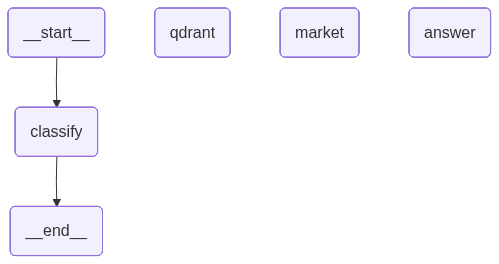

In [49]:
graph = StateGraph(HRState)

# Узлы
graph.add_node("classify", classify_node)
graph.add_node("qdrant",   qdrant_node)
graph.add_node("market",   market_node)
graph.add_node("answer",   answer_node)

# Рёбра
graph.add_edge(START, "classify")
graph.add_conditional_edges("classify", route_after_classify)  # → qdrant / market / answer
graph.add_conditional_edges("qdrant",   route_after_qdrant)    # → market / answer
graph.add_edge("market", "answer")
graph.add_edge("answer", END)

app = graph.compile()
display(Image(app.get_graph().draw_mermaid_png()))

---
### 6. Тестируем

Каждый запрос попадёт в свой маршрут в зависимости от `query_type`.
Смотрим на `print`-вывод из узлов — видим какие узлы отработали.

In [51]:
def run_query(query: str) -> dict:
    display(Markdown(f"---\n**Запрос:** {query}"))
    initial_state = {
        "messages":       [HumanMessage(content=query)],
        "query_type":     "",
        "qdrant_results": "",
        "market_results": "",
    }
    result = app.invoke(
        initial_state,
        config={"run_name": "hr_graph_v2", "tags": ["02_01"]},
    )
    display(Markdown(f"**Маршрут:** `query_type='{result['query_type']}'`"))
    display(Markdown(result["messages"][-1].content))
    return result

In [52]:
# Маршрут: classify → qdrant → answer
r1 = run_query("Найди вакансии Data Scientist в спортивной компании")

---
**Запрос:** Найди вакансии Data Scientist в спортивной компании

  classify → 'vacancies'
  qdrant → найдено 3 вакансий


**Маршрут:** `query_type='vacancies'`

В базе есть одна вакансия Data Scientist в спортивной компании:

=== ВАКАНСИЯ 3 ===
ID: N/A
Должность: Дата-сайентист
Компания: Спортлевел
Локация: Москва
Скиллы: Python, SQL, scikit-learn, PyTorch, Pandas, NumPy, Matplotlib, Plotly, Metabase, PostgreSQL, MongoDB
Описание: Привет, мы Спортлевел! IT компания в области SportTech, мы разрабатываем и предоставляем передовые спортивные технологии для компаний со всего мира, сотрудничаем со многими спортивными федерациями и букмекерами. Сейчас мы ищем Middle+ или Senior Data Science , который присоединится к нашей команде. ...

In [54]:
# Маршрут: classify → market → answer
r2 = run_query("Какие зарплаты у ML-инженеров junior/middle/senior в России? И дай источники на них")

---
**Запрос:** Какие зарплаты у ML-инженеров junior/middle/senior в России? И дай источники на них

  classify → 'salary'
  market → 1500 символов


**Маршрут:** `query_type='salary'`

К сожалению, у меня нет точных данных о зарплатах ML-инженеров junior/middle/senior в России. Однако, исходя из предоставленной информации, можно сделать вывод, что средняя зарплата ML-инженера в России составляет 145 000 ₽ на руки.

Для более точной информации о зарплатах junior/middle/senior ML-инженеров, я рекомендую обратиться к источникам, таким как:

* Dream Job (сайт отзывов сотрудников)
* Хабр Карьера (платформа для поиска работы и карьерного роста в IT)

На этих ресурсах можно найти обзоры зарплат, вакансии и отзывы сотрудников, что может помочь получить более точную информацию о зарплатах ML-инженеров в России.

In [22]:
# Маршрут: classify → qdrant → market → answer
r3 = run_query("Найди вакансии DS в финтехе и расскажи про зарплаты на рынке")

---
**Запрос:** Найди вакансии DS в финтехе и расскажи про зарплаты на рынке

  classify → 'both'
  qdrant → найдено 3 вакансий
  market → 601 символов


**Маршрут:** `query_type='both'`

На основе предоставленной информации, я нашел следующие вакансии в финтехе, связанные с данными (DS):

1. **Маркетолог-аналитик** в компании "Точка" (Москва) - требует навыков Python и SQL.
2. **BI-аналитик, аналитик данных** в компании "МТС Финтех" (Москва) - требует навыков SQL, Tableau, PostgreSQL и Oracle.

Что касается зарплат на рынке, то согласно источнику "Сколько зарабатывают в российском IT?" от getmatch, точные зарплаты не указаны. Однако, есть информация о том, что можно найти детальную информацию по рынку, зарегистрировавшись или войдя на сайт.

Кроме того, есть информация от Марии Штейн (mary-shteyn) о том, что руководитель продуктовых дизайнеров БКС Финтеха может зарабатывать от 420 000 ₽. Однако, это не связано напрямую с вакансиями DS в финтехе.

In [55]:
# Маршрут: classify → answer  (без поиска)
r4 = run_query("Привет! Посоветуй как составить хорошее резюме")

---
**Запрос:** Привет! Посоветуй как составить хорошее резюме

  classify → 'vacancies'
  qdrant → найдено 3 вакансий


**Маршрут:** `query_type='vacancies'`

Привет! Составление хорошего резюме - это важный шаг в поиске работы. Вот несколько советов, которые могут тебе помочь:

1. **Определите цель**: Прежде чем начать составлять резюме, определите, какой работы ты ищешь и какие навыки и опыт у тебя есть, которые могут быть полезны для этой работы.
2. **Используйте четкий и краткий язык**: Избегайте использования слишком длинных предложений и сложных слов. Используйте простой и понятный язык, чтобы описать свои навыки и опыт.
3. **Укажите контактную информацию**: Убедись, что твое резюме содержит актуальную контактную информацию, такую как адрес электронной почты, номер телефона и ссылка на профиль в социальных сетях (если применимо).
4. **Составьте список навыков**: Перечисли свои навыки и опыт, которые могут быть полезны для работы, на которую ты претендуешь. Это может включать языки программирования, инструменты, программное обеспечение и т.д.
5. **Опишите опыт работы**: Опиши свой опыт работы, включая названия компаний, должности и периоды работы. Укажи свои достижения и ответственность на каждой работе.
6. **Добавьте образование и сертификаты**: Укажи свое образование и сертификаты, которые могут быть полезны для работы.
7. **Используйте ключевые слова**: Используй ключевые слова из описания работы, на которую ты претендуешь, чтобы показать, что ты соответствуешь требованиям.
8. **Проверьте орфографию и грамматику**: Убедись, что твое резюме не содержит ошибок в орфографии и грамматике.

Также, если ты хочешь увеличить шансы на то, что твое резюме будет прочитано, ты можешь использовать инструменты, такие как ChatGPT, для автоматизации обработки текста и корректировки твоего резюме.

Например, если ты хочешь подать заявку на одну из вакансий, которые я видел ранее, ты можешь использовать ключевые слова из описания работы, такие как "GPT" или "нейросети", чтобы показать, что ты соответствуешь требованиям.

Надеюсь, эти советы помогут тебе составить хорошее резюме!

In [56]:
client.close()